# Advanced Analytics & Risk Metrics

## Bluestock Fintech Capstone Project

This notebook performs advanced mutual fund analytics, including:

- Historical VaR (95%) and CVaR
- Rolling 90-Day Sharpe Ratio
- Investor Cohort Analysis
- SIP Continuity Analysis
- Sector HHI Concentration
- Risk-Based Fund Recommendation

**Author:** Chandra Shekar  
**Date:** July 2026

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use("default")

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Project folders
DATA = Path("../data/processed")
REPORTS = Path("../reports/performance")

REPORTS.mkdir(parents=True, exist_ok=True)

# Load datasets
fund = pd.read_csv(DATA / "clean_01_fund_master.csv")
nav = pd.read_csv(DATA / "clean_02_nav_history.csv")
performance = pd.read_csv(DATA / "clean_07_scheme_performance.csv")
transactions = pd.read_csv(DATA / "clean_08_investor_transactions.csv")
portfolio = pd.read_csv(DATA / "clean_09_portfolio_holdings.csv")

print("Datasets loaded successfully.\n")

print("Fund Master:", fund.shape)
print("NAV History:", nav.shape)
print("Performance:", performance.shape)
print("Transactions:", transactions.shape)
print("Portfolio:", portfolio.shape)

Datasets loaded successfully.

Fund Master: (40, 15)
NAV History: (46000, 3)
Performance: (40, 19)
Transactions: (32778, 13)
Portfolio: (322, 8)


In [3]:
# Convert date columns
nav["date"] = pd.to_datetime(nav["date"])
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)
portfolio["portfolio_date"] = pd.to_datetime(
    portfolio["portfolio_date"]
)

print("Date columns converted.")

Date columns converted.


## 1. Historical Value at Risk (VaR) & Conditional Value at Risk (CVaR)

Historical Value at Risk (VaR) estimates the maximum expected daily loss at a given confidence level based on historical returns.

Conditional Value at Risk (CVaR), also called Expected Shortfall, measures the average loss beyond the VaR threshold.

In this section, VaR and CVaR are computed for all mutual fund schemes using historical daily NAV returns.

In [4]:
# Sort NAV history
nav = nav.sort_values(["amfi_code", "date"])

# Calculate daily percentage returns
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

# Remove first NaN return of each fund
nav_returns = nav.dropna(subset=["daily_return"]).copy()

print("Daily returns calculated.")
print(nav_returns.head())

Daily returns calculated.
      amfi_code       date       nav  daily_return
5751     100016 2022-01-04  515.0971     -0.010306
5752     100016 2022-01-05  521.7239      0.012865
5753     100016 2022-01-06  515.7880     -0.011377
5754     100016 2022-01-07  515.1639     -0.001210
5755     100016 2022-01-10  510.7136     -0.008639


In [5]:
risk_metrics = []

for code, group in nav_returns.groupby("amfi_code"):

    returns = group["daily_return"]

    # Historical VaR (95%)
    var95 = np.percentile(returns, 5)

    # Conditional VaR
    cvar95 = returns[returns <= var95].mean()

    risk_metrics.append({
        "amfi_code": code,
        "VaR_95": var95,
        "CVaR_95": cvar95
    })

risk_metrics = pd.DataFrame(risk_metrics)

risk_metrics.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [6]:
risk_metrics = risk_metrics.merge(
    performance[
        [
            "amfi_code",
            "scheme_name",
            "fund_house",
            "risk_grade"
        ]
    ],
    on="amfi_code",
    how="left"
)

risk_metrics.head()

,amfi_code,VaR_95,CVaR_95,scheme_name,fund_house,risk_grade
0,100016,-0.014364,-0.018060,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Moderate
1,100025,-0.003793,-0.004994,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Low
2,100033,-0.019034,-0.023456,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,High
3,101206,-0.013282,-0.017439,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Moderate
4,101207,-0.026021,-0.032459,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Very High


In [7]:
risk_metrics = risk_metrics.sort_values(
    "VaR_95"
)

risk_metrics.head(10)

,amfi_code,VaR_95,CVaR_95,scheme_name,fund_house,risk_grade
22,119599,-0.026859,-0.032384,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Very High
17,119095,-0.026188,-0.031667,Axis Small Cap Fund - Regular - Growth,Axis Mutual Fund,Very High
4,101207,-0.026021,-0.032459,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Very High
11,118634,-0.025438,-0.032304,Nippon India Small Cap Fund - Regular - Growth,Nippon India MF,Very High
21,119598,-0.024507,-0.030595,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Very High
39,149324,-0.023483,-0.031036,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Very High
7,102886,-0.019220,-0.023251,UTI Mid Cap Fund - Regular - Growth,UTI Mutual Fund,High
2,100033,-0.019034,-0.023456,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,High
25,120505,-0.018892,-0.024342,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,High
16,119094,-0.018480,-0.024260,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,High


In [8]:
from pathlib import Path

REPORTS = Path("../reports/performance")
REPORTS.mkdir(parents=True, exist_ok=True)

risk_metrics.to_csv(
    REPORTS / "var_cvar_report.csv",
    index=False
)

print("Saved:", REPORTS / "var_cvar_report.csv")

Saved: ..\reports\performance\var_cvar_report.csv


## 2. Rolling 90-Day Sharpe Ratio

The rolling Sharpe Ratio measures the evolution of risk-adjusted returns over time.

A 90-day rolling window is used to compute the average daily return divided by the rolling standard deviation and annualized using √252 trading days.

The visualization compares five representative mutual funds.

In [9]:
top5_codes = (
    performance
    .sort_values("aum_crore", ascending=False)
    .head(5)["amfi_code"]
)

top5_codes

35    148568
21    120842
17    118634
37    149322
32    102886
Name: amfi_code, dtype: int64

In [10]:
rolling_sharpe = []

for code in top5_codes:

    fund = nav_returns[
        nav_returns["amfi_code"] == code
    ].copy()

    fund = fund.sort_values("date")

    fund["rolling_mean"] = (
        fund["daily_return"]
        .rolling(window=90)
        .mean()
    )

    fund["rolling_std"] = (
        fund["daily_return"]
        .rolling(window=90)
        .std()
    )

    fund["rolling_sharpe"] = (
        fund["rolling_mean"]
        / fund["rolling_std"]
    ) * np.sqrt(252)

    name = performance.loc[
        performance["amfi_code"] == code,
        "scheme_name"
    ].values[0]

    fund["scheme_name"] = name

    rolling_sharpe.append(fund)

rolling_sharpe = pd.concat(
    rolling_sharpe,
    ignore_index=True
)

rolling_sharpe.head()

,amfi_code,date,nav,daily_return,rolling_mean,rolling_std,rolling_sharpe,scheme_name
0,148568,2022-01-04,85.4096,0.015865,NaN,NaN,NaN,Mirae Asset Emerging Bluechip Fund - Regular -...
1,148568,2022-01-05,84.7554,-0.007660,NaN,NaN,NaN,Mirae Asset Emerging Bluechip Fund - Regular -...
2,148568,2022-01-06,84.3563,-0.004709,NaN,NaN,NaN,Mirae Asset Emerging Bluechip Fund - Regular -...
3,148568,2022-01-07,84.9469,0.007001,NaN,NaN,NaN,Mirae Asset Emerging Bluechip Fund - Regular -...
4,148568,2022-01-10,84.0017,-0.011127,NaN,NaN,NaN,Mirae Asset Emerging Bluechip Fund - Regular -...


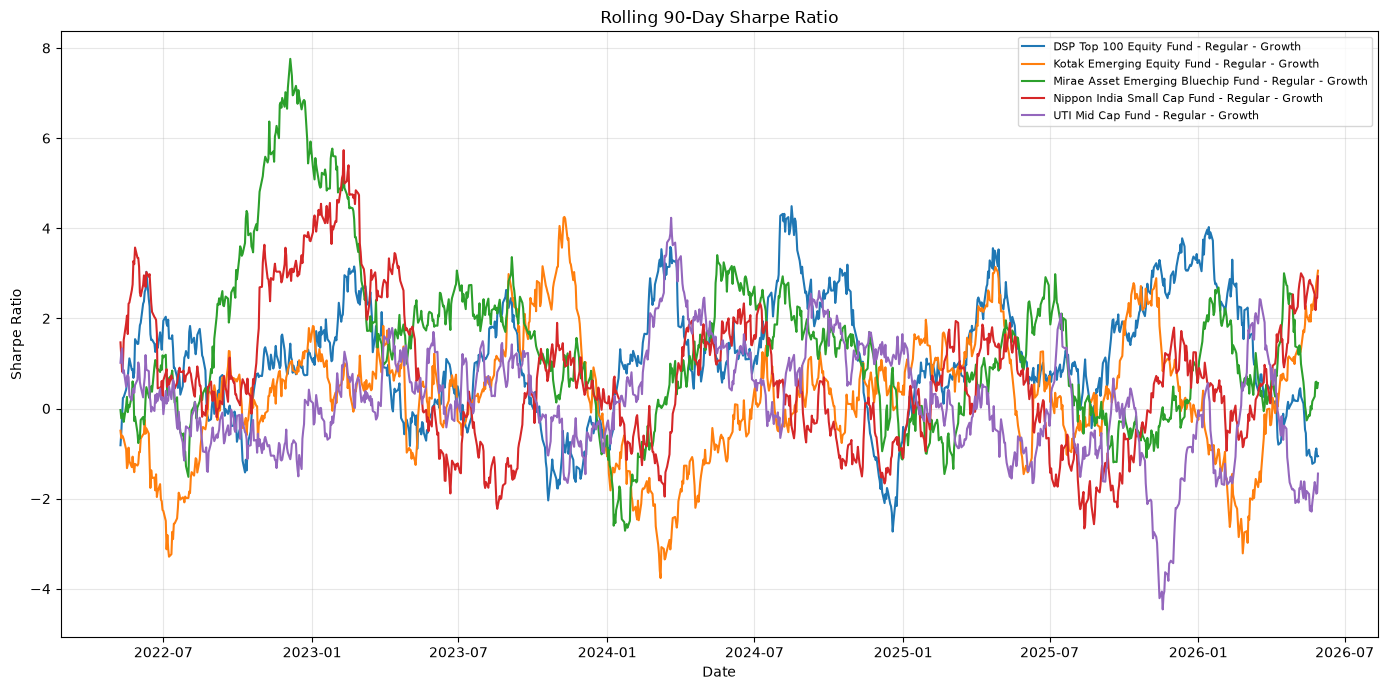

In [11]:
plt.figure(figsize=(14,7))

for name, group in rolling_sharpe.groupby("scheme_name"):

    plt.plot(
        group["date"],
        group["rolling_sharpe"],
        label=name
    )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")

plt.legend(fontsize=8)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

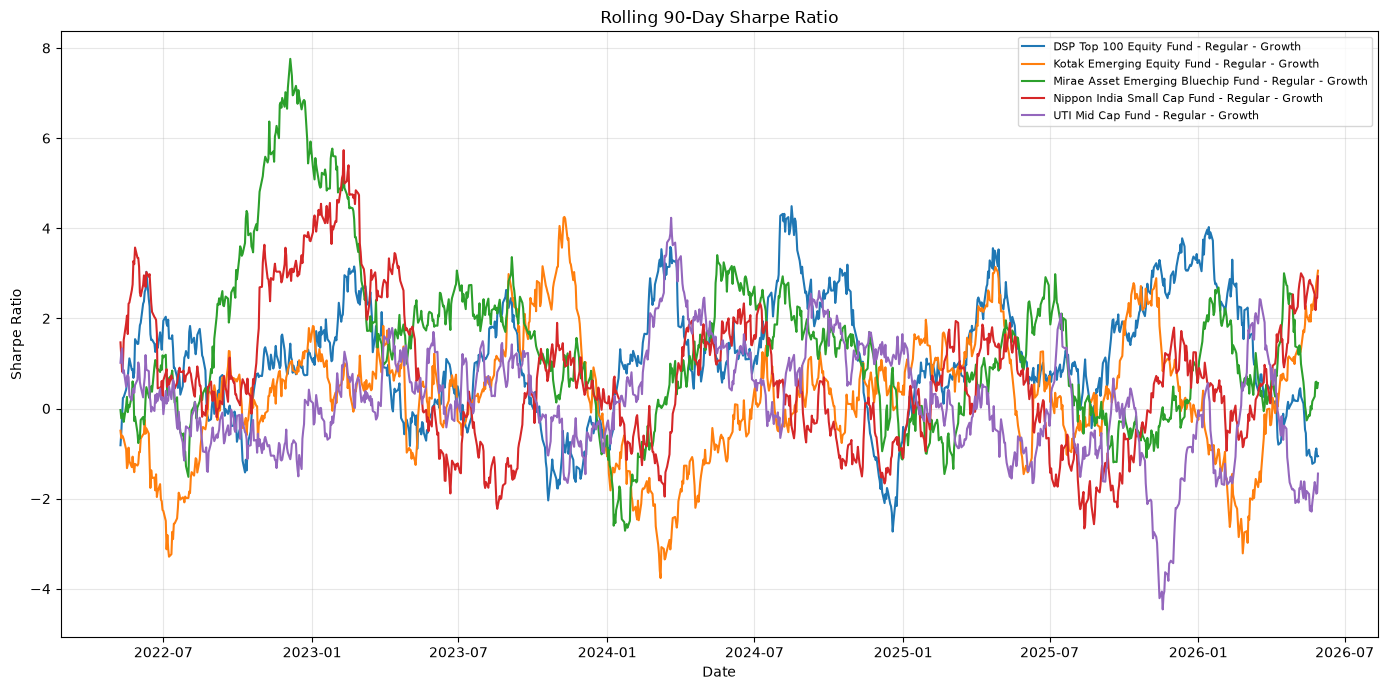

In [12]:
REPORTS = Path("../reports/performance")

plt.figure(figsize=(14,7))

for name, group in rolling_sharpe.groupby("scheme_name"):

    plt.plot(
        group["date"],
        group["rolling_sharpe"],
        label=name
    )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")

plt.legend(fontsize=8)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    REPORTS / "rolling_sharpe_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 3. Investor Cohort Analysis

Investor Cohort Analysis groups investors based on the year of their first investment transaction.

For each cohort, the following metrics are computed:

- Average investment amount
- Total investment amount
- Most preferred mutual fund

This analysis helps understand investor behaviour across different onboarding years.

In [13]:
transactions = transactions.sort_values(
    ["investor_id", "transaction_date"]
)

first_txn = (
    transactions
    .groupby("investor_id")["transaction_date"]
    .min()
    .reset_index()
)

first_txn["cohort_year"] = (
    first_txn["transaction_date"]
    .dt.year
)

first_txn.head()

,investor_id,transaction_date,cohort_year
0,INV000001,2024-11-04,2024
1,INV000002,2024-03-29,2024
2,INV000003,2024-07-16,2024
3,INV000004,2024-03-16,2024
4,INV000005,2024-04-27,2024


In [14]:
transactions = transactions.merge(
    first_txn[
        ["investor_id", "cohort_year"]
    ],
    on="investor_id",
    how="left"
)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024
1,INV000001,2025-01-14,148569,Lumpsum,189483,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024
2,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2024
3,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024
4,INV000002,2024-07-14,149323,Lumpsum,153187,Maharashtra,Pune,T30,46-55,Male,24.0,UPI,Verified,2024


In [15]:
avg_sip = (
    transactions
    .groupby("cohort_year")["amount_inr"]
    .mean()
    .reset_index(name="avg_amount")
)

avg_sip

,cohort_year,avg_amount
0,2024,107422.541832
1,2025,109158.577061


In [16]:
total_invested = (
    transactions
    .groupby("cohort_year")["amount_inr"]
    .sum()
    .reset_index(name="total_invested")
)

total_invested

,cohort_year,total_invested
0,2024,3491125187
1,2025,30455243


In [17]:
fund_pref = (
    transactions
    .groupby(
        ["cohort_year", "amfi_code"]
    )
    .size()
    .reset_index(name="count")
)

In [18]:
fund_pref = fund_pref.merge(
    performance[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

fund_pref.head()

,cohort_year,amfi_code,count,scheme_name
0,2024,100016,830,HDFC Top 100 Fund - Regular Plan - Growth
1,2024,100025,791,HDFC Short Term Debt Fund - Regular - Growth
2,2024,100033,781,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,2024,101206,803,ABSL Frontline Equity Fund - Regular - Growth
4,2024,101207,844,ABSL Small Cap Fund - Regular - Growth


In [19]:
top_fund = (
    fund_pref
    .sort_values(
        "count",
        ascending=False
    )
    .groupby("cohort_year")
    .first()
    .reset_index()
)

top_fund

,cohort_year,amfi_code,count,scheme_name
0,2024,148568,874,Mirae Asset Emerging Bluechip Fund - Regular -...
1,2025,120507,12,ICICI Pru Liquid Fund - Regular - Growth


In [20]:
cohort_report = (
    avg_sip
    .merge(total_invested, on="cohort_year")
    .merge(
        top_fund[
            [
                "cohort_year",
                "scheme_name"
            ]
        ],
        on="cohort_year"
    )
)

cohort_report

,cohort_year,avg_amount,total_invested,scheme_name
0,2024,107422.541832,3491125187,Mirae Asset Emerging Bluechip Fund - Regular -...
1,2025,109158.577061,30455243,ICICI Pru Liquid Fund - Regular - Growth


## 4. SIP Continuity Analysis

This analysis identifies investors with regular SIP contributions.

For investors having at least six SIP transactions, the average number of days between consecutive SIP investments is calculated.

Investors whose average gap exceeds 35 days are flagged as **At Risk**, indicating possible discontinuation of their SIP investments.

In [24]:
sip_txn = transactions[
    transactions["transaction_type"] == "SIP"
].copy()

sip_txn = sip_txn.sort_values(
    ["investor_id", "transaction_date"]
)

sip_txn.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024
2,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2024
3,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024
5,INV000002,2024-09-21,120841,SIP,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024
8,INV000002,2025-05-17,119094,SIP,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,2024


In [25]:
sip_txn["gap_days"] = (
    sip_txn
    .groupby("investor_id")["transaction_date"]
    .diff()
    .dt.days
)

sip_txn.head(10)

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,gap_days
0,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024,NaN
2,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2024,76.0
3,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,NaN
5,INV000002,2024-09-21,120841,SIP,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,176.0
8,INV000002,2025-05-17,119094,SIP,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,2024,238.0
9,INV000003,2024-07-16,101207,SIP,2676,Gujarat,Ahmedabad,T30,26-35,Female,10.6,Mandate,Verified,2024,NaN
10,INV000003,2025-03-11,149322,SIP,15185,Gujarat,Ahmedabad,T30,26-35,Female,10.6,Mandate,Verified,2024,238.0
11,INV000004,2024-03-16,101208,SIP,960,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024,NaN
13,INV000004,2024-04-11,119095,SIP,20602,Punjab,Chandigarh,T30,26-35,Male,20.0,Net Banking,Verified,2024,26.0
16,INV000004,2024-05-09,120844,SIP,541,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,2024,28.0


In [26]:
sip_summary = (
    sip_txn
    .groupby("investor_id")
    .agg(
        sip_count=("transaction_date", "count"),
        avg_gap_days=("gap_days", "mean")
    )
    .reset_index()
)

sip_summary = sip_summary[
    sip_summary["sip_count"] >= 6
]

sip_summary.head()

,investor_id,sip_count,avg_gap_days
3,INV000004,6,85.400000
7,INV000008,6,70.400000
9,INV000010,6,64.800000
10,INV000011,7,40.166667
11,INV000012,8,57.000000


In [27]:
sip_summary["status"] = np.where(
    sip_summary["avg_gap_days"] > 35,
    "At Risk",
    "Active"
)

sip_summary.head()

,investor_id,sip_count,avg_gap_days,status
3,INV000004,6,85.400000,At Risk
7,INV000008,6,70.400000,At Risk
9,INV000010,6,64.800000,At Risk
10,INV000011,7,40.166667,At Risk
11,INV000012,8,57.000000,At Risk


In [28]:
sip_summary["status"].value_counts()

status
At Risk    1332
Active       30
Name: count, dtype: int64

## 5. Fund Recommendation Engine

A simple recommendation system is created using the existing performance dataset.

The user selects a preferred risk appetite, and the model recommends the top three mutual funds having the highest Sharpe Ratio within the corresponding risk grade.

In [29]:
risk_level = "Moderate"

performance["risk_grade"].unique()

<StringArray>
['Moderate', 'Very High', 'Low', 'High', 'Moderately High']
Length: 5, dtype: str

In [30]:
recommendations = (
    performance[
        performance["risk_grade"] == risk_level
    ]
    .sort_values(
        "sharpe_ratio",
        ascending=False
    )
    [
        [
            "scheme_name",
            "fund_house",
            "category",
            "risk_grade",
            "sharpe_ratio",
            "return_3yr_pct",
            "return_5yr_pct",
            "expense_ratio_pct",
        ]
    ]
    .head(3)
)

recommendations

,scheme_name,fund_house,category,risk_grade,sharpe_ratio,return_3yr_pct,return_5yr_pct,expense_ratio_pct
5,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Large Cap,Moderate,1.06,14.84,11.32,1.55
34,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Large Cap,Moderate,1.06,14.81,12.68,1.46
11,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Large Cap,Moderate,1.03,14.41,13.02,0.80


In [31]:
print(f"Top 3 recommendations for {risk_level} risk\n")

print(recommendations.to_string(index=False))

Top 3 recommendations for Moderate risk

                                  scheme_name          fund_house  category risk_grade  sharpe_ratio  return_3yr_pct  return_5yr_pct  expense_ratio_pct
    HDFC Top 100 Fund - Regular Plan - Growth    HDFC Mutual Fund Large Cap   Moderate          1.06           14.84           11.32               1.55
Mirae Asset Large Cap Fund - Regular - Growth      Mirae Asset MF Large Cap   Moderate          1.06           14.81           12.68               1.46
    ICICI Pru Bluechip Fund - Direct - Growth ICICI Prudential MF Large Cap   Moderate          1.03           14.41           13.02               0.80


In [32]:
REPORTS = Path("../reports/performance")
REPORTS.mkdir(exist_ok=True)

recommendations.to_csv(
    REPORTS / "fund_recommendations.csv",
    index=False
)

## 6. Sector HHI (Herfindahl-Hirschman Index)

The Herfindahl-Hirschman Index (HHI) measures portfolio concentration by summing the squared portfolio weights of all holdings.

Higher HHI indicates a more concentrated portfolio, while lower HHI represents better diversification.

This analysis compares concentration across all equity mutual funds.

In [33]:
equity_categories = [
    "Large Cap",
    "Mid Cap",
    "Small Cap",
    "Large & Mid Cap",
    "Flexi Cap",
    "ELSS",
    "Sectoral/Thematic",
    "Value/Contra",
    "Focused Fund",
    "Multi Cap"
]

equity_funds = performance[
    performance["category"].isin(equity_categories)
]["amfi_code"]

equity_portfolio = portfolio[
    portfolio["amfi_code"].isin(equity_funds)
].copy()

equity_portfolio.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [34]:
hhi = (
    equity_portfolio
    .groupby("amfi_code")["weight_pct"]
    .apply(lambda x: (x / 100).pow(2).sum())
    .reset_index(name="HHI")
)

hhi.head()

,amfi_code,HHI
0,100016,0.139534
1,100033,0.147592
2,101206,0.129332
3,101207,0.200700
4,102886,0.114693


In [35]:
hhi = hhi.merge(
    performance[
        [
            "amfi_code",
            "scheme_name",
            "fund_house",
            "category"
        ]
    ],
    on="amfi_code",
    how="left"
)

hhi.head()

,amfi_code,HHI,scheme_name,fund_house,category
0,100016,0.139534,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Large Cap
1,100033,0.147592,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Mid Cap
2,101206,0.129332,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Large Cap
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Small Cap
4,102886,0.114693,UTI Mid Cap Fund - Regular - Growth,UTI Mutual Fund,Mid Cap


In [36]:
hhi = hhi.sort_values(
    "HHI",
    ascending=False
)

hhi.head(10)

,amfi_code,HHI,scheme_name,fund_house,category
9,119092,0.206448,Axis Bluechip Fund - Regular - Growth,Axis Mutual Fund,Large Cap
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Small Cap
16,119599,0.174751,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap
6,118632,0.168298,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF,Large Cap
26,148568,0.167930,Mirae Asset Emerging Bluechip Fund - Regular -...,Mirae Asset MF,Large & Mid Cap
19,120505,0.157570,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Mid Cap
24,125498,0.152414,HDFC Mid-Cap Opportunities Fund - Direct - Growth,HDFC Mutual Fund,Mid Cap
20,120841,0.149680,Kotak Bluechip Fund - Regular - Growth,Kotak Mahindra MF,Large Cap
27,148569,0.149396,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,ELSS
1,100033,0.147592,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Mid Cap


In [37]:
REPORTS = Path("../reports/performance")

hhi.to_csv(
    REPORTS / "sector_hhi_report.csv",
    index=False
)

# 7. Key Insights

### 1. Value at Risk (VaR) Analysis
Small-cap and high-risk equity funds recorded the most negative VaR and CVaR values, indicating greater downside risk during adverse market conditions.

### 2. Rolling Sharpe Ratio
The rolling 90-day Sharpe Ratio varied significantly across funds, showing that risk-adjusted performance changes over time rather than remaining constant.

### 3. Investor Cohort Behaviour
The 2024 investor cohort contributed the majority of total investments and maintained a higher average SIP amount compared to the smaller 2025 cohort.

### 4. SIP Continuity
Most investors with six or more SIP transactions were classified as "At Risk" due to average transaction gaps exceeding 35 days, indicating irregular investment behaviour.

### 5. Portfolio Concentration (HHI)
Several equity funds exhibited relatively high HHI values, suggesting concentrated sector allocations, while others maintained better diversification through lower concentration scores.